In [83]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [ ]:
READ_CSV = {
    "dist": "./dist_norm_nd/",
    "cos": "./cos_norm_nd/",
}
SAVE_PATH = "./dist_norm_nd_hm/"
CALC_MODES = ['dist', 'cos']
CALC_LEGEND = {
    'dist': 'euclidean distance',
    'cos': 'cosine similarity'
}
CALC_MODE_CM = {
    'dist': 'viridis',
    'cos': 'viridis_r'
}
DATASETS = ['fmasmallx']
MODELS = ['AudioCLIP', 'CLAP', 'WAV2CLIP']

tf_dict_params = {
    "pitchshift": [-24, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, "id", 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 24],
    "timestretch": [1/2.0, 1/1.5, 1/1.4, 1/1.3, 1/1.2, 1/1.1, "id", 1.1, 1.2, 1.3, 1.4, 1.5, 2.0],
    "highpass": ["id", 500, 1000, 2000, 4000, 8000, 16000],
    "lowpass": ["id", 16000, 8000, 4000, 2000, 1000, 500],
    "clipper": ["id", 0.8, 0.4, 0.2, 0.1],
    "noiseadder": ["id", -100, -80, -60, -40, -20, 0],
    "bitcrush": ["id", 14, 12, 10, 8, 6, 4],
    "gain": [1/3.0, 1/2.0, 1/1.5, 1/1.2, "id", 1.2, 1.5, 2.0, 3.0],
}

tf_dict_names = {
    "pitchshift": "Pitchshift",
    "timestretch": "Timestretch",
    "highpass": "Highpass Filter",
    "lowpass": "Lowpass Filter",
    "clipper": "Clipper",
    "noiseadder": "Noiseadder",
    "bitcrush": "Bitcrusher",
    "gain": "Gain",
}

tf_dict_legends = {
    "pitchshift": "semitones",
    "timestretch": "fraction",
    "highpass": "cutoff (Hz)",
    "lowpass": "cutoff (Hz)",
    "clipper": "ceiling",
    "noiseadder": "noise dB",
    "bitcrush": "bit depth",
    "gain": "fraction",
}

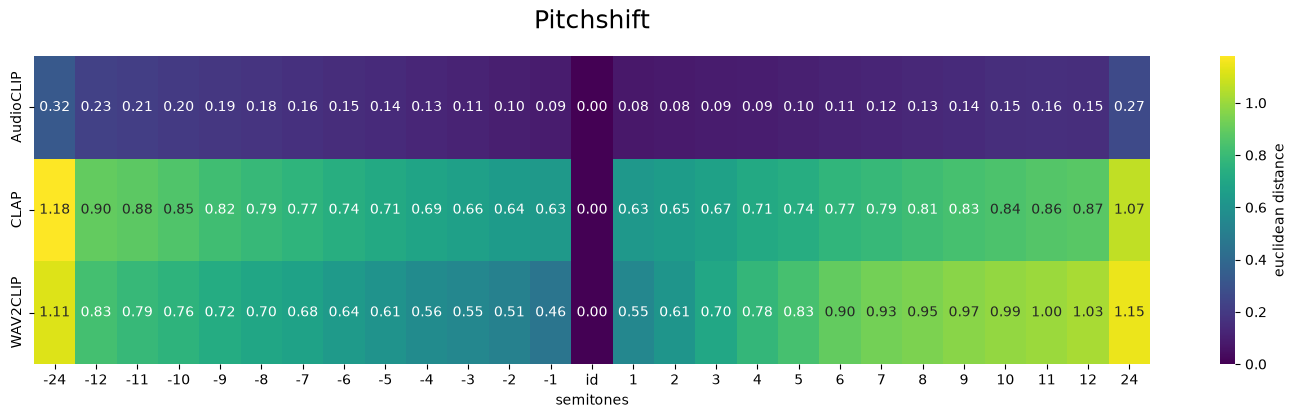

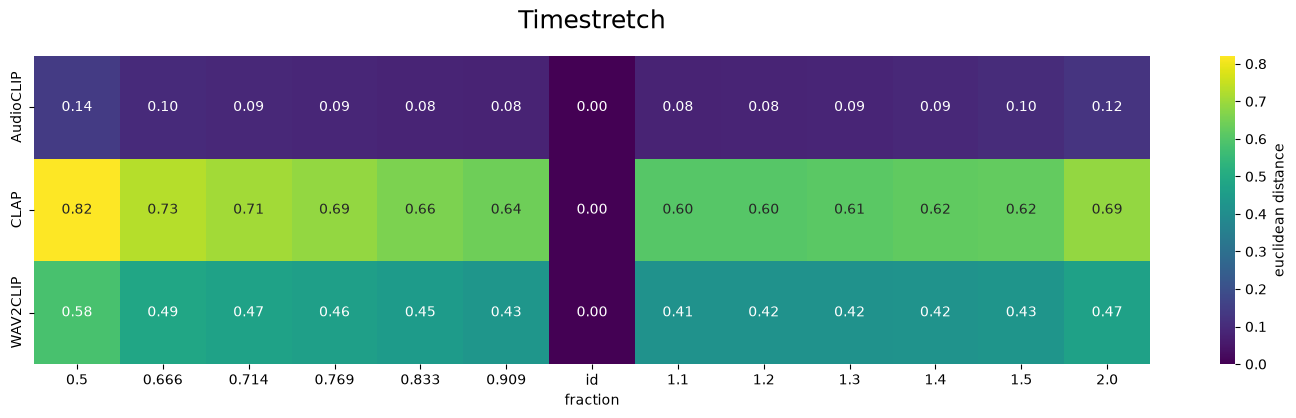

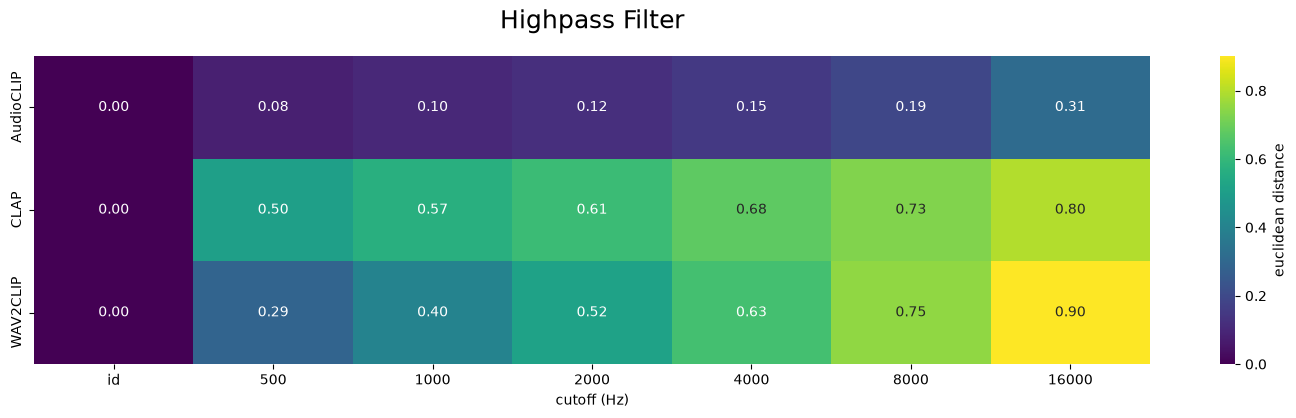

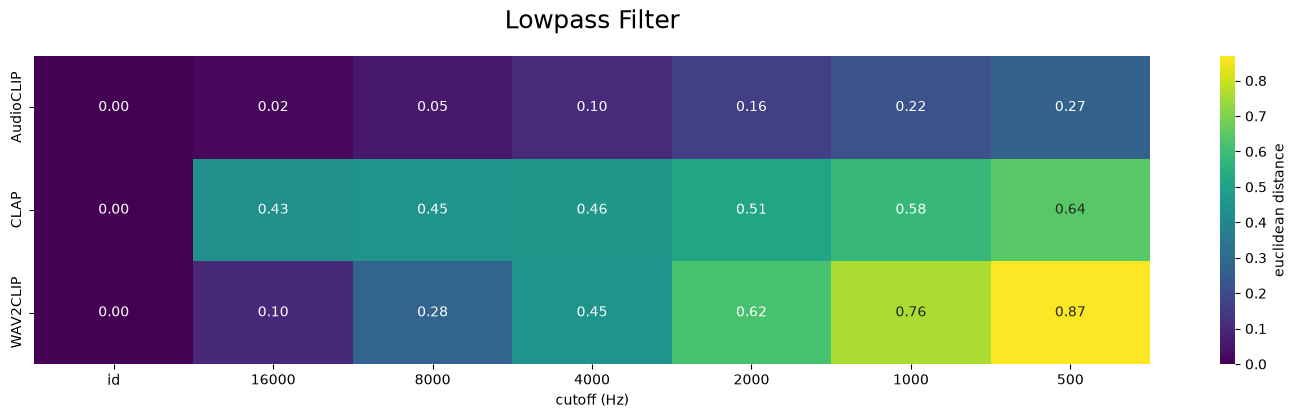

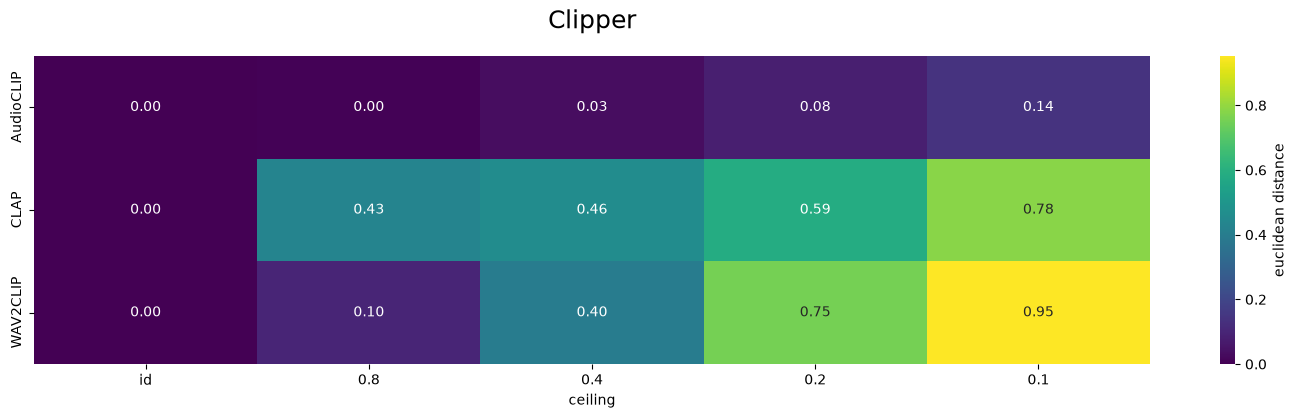

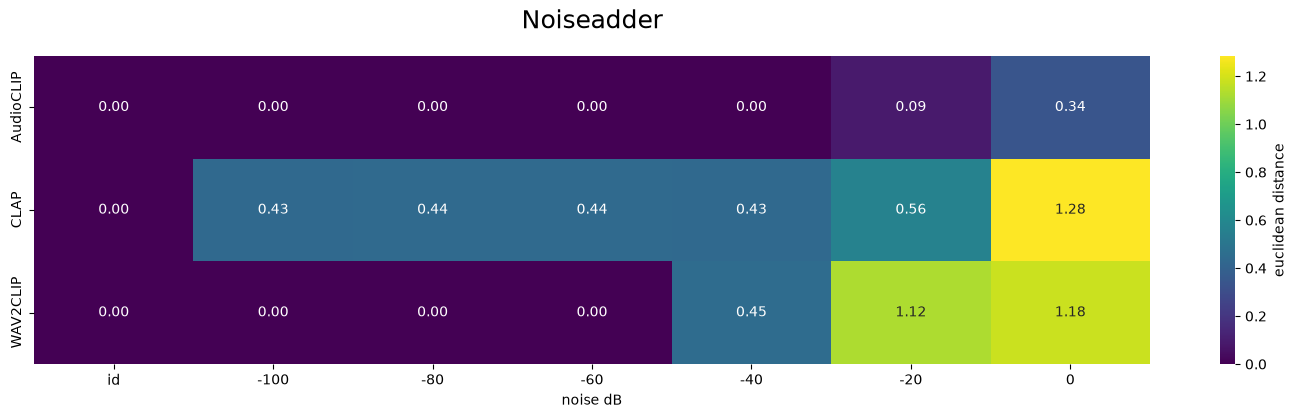

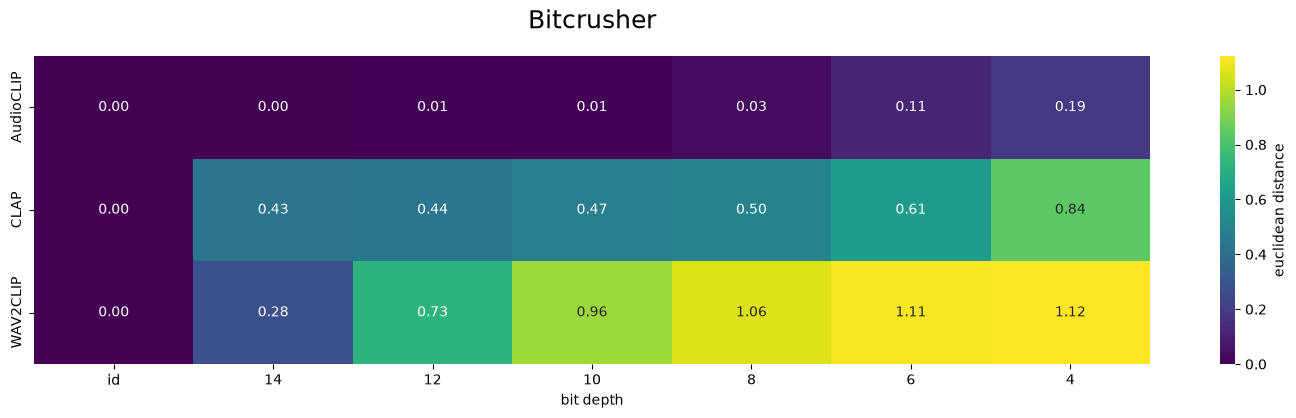

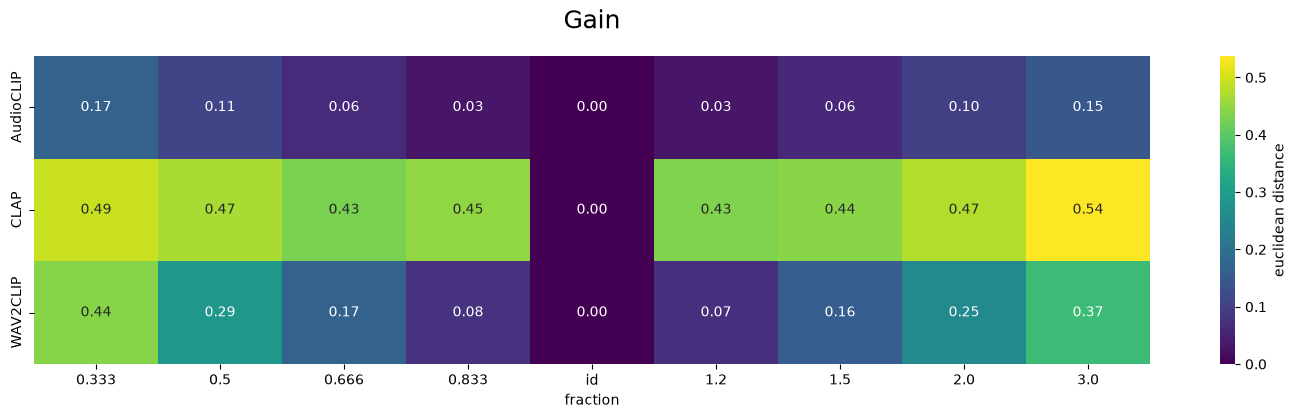

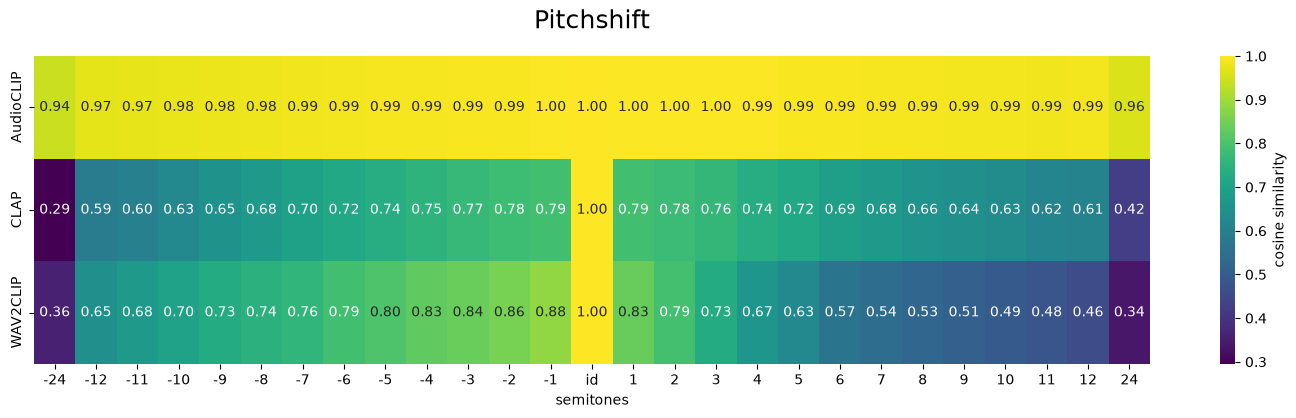

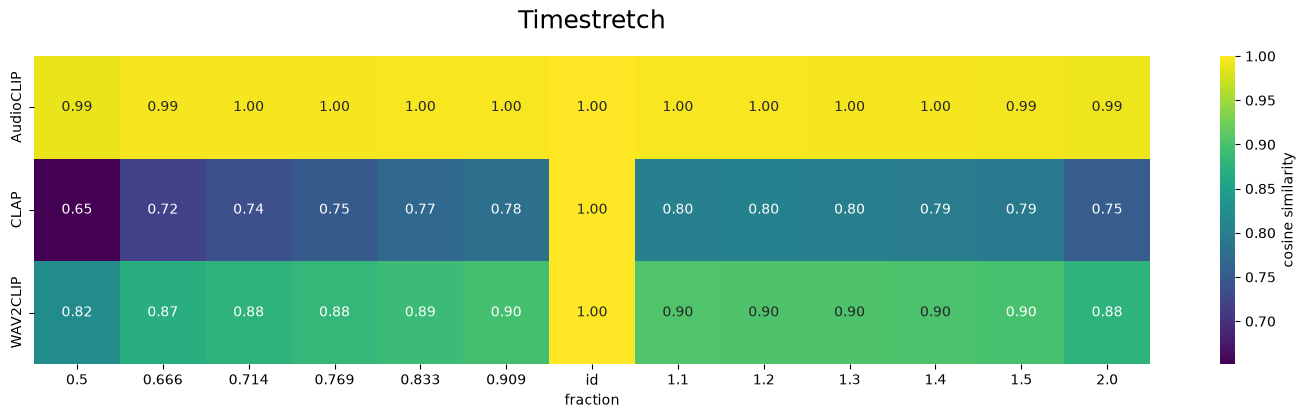

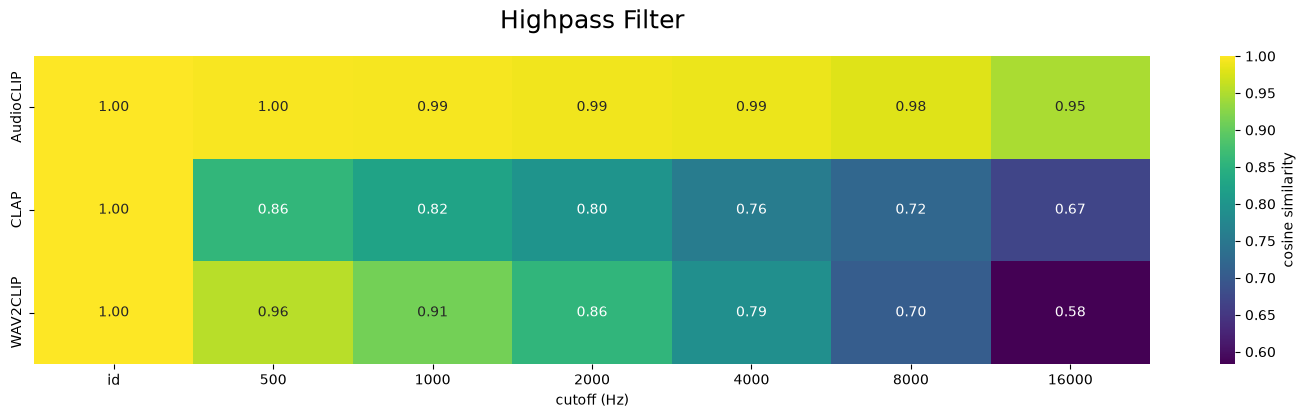

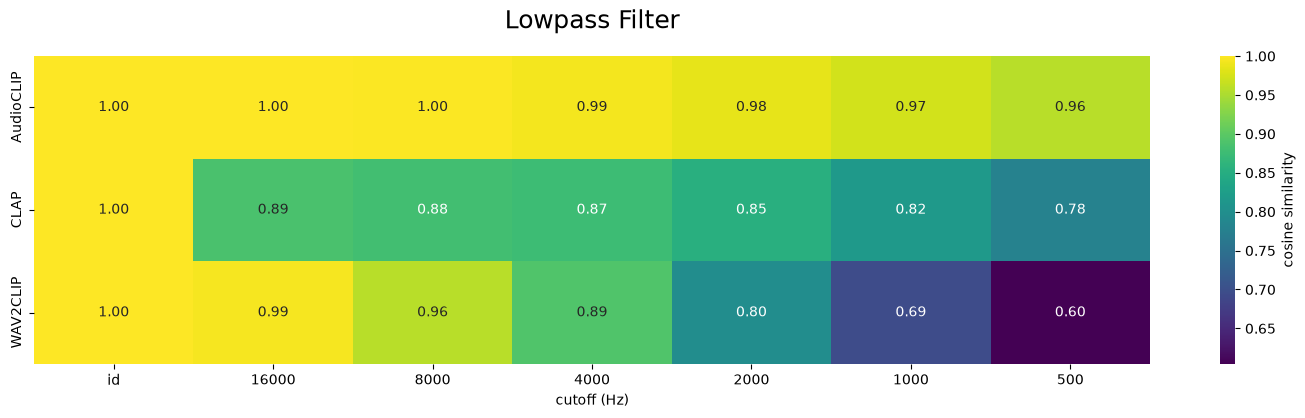

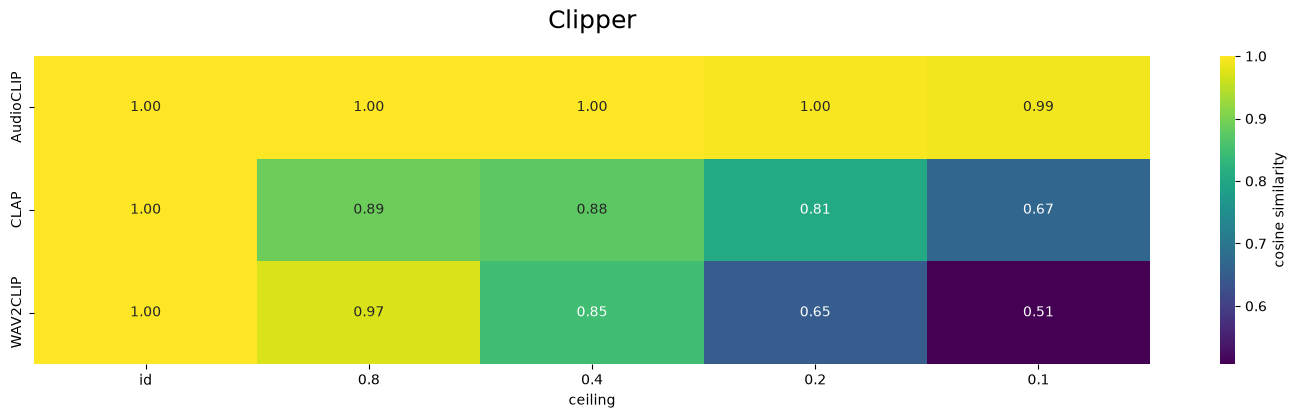

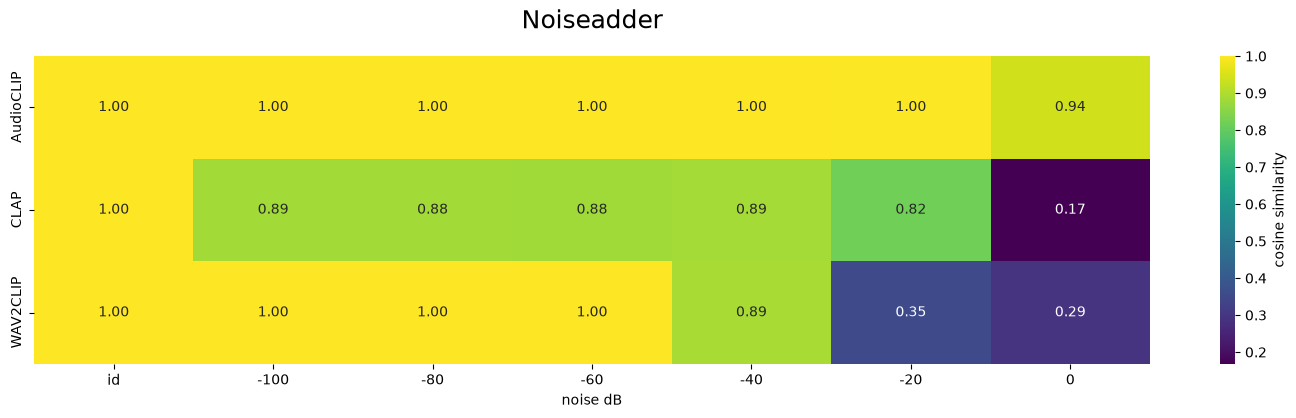

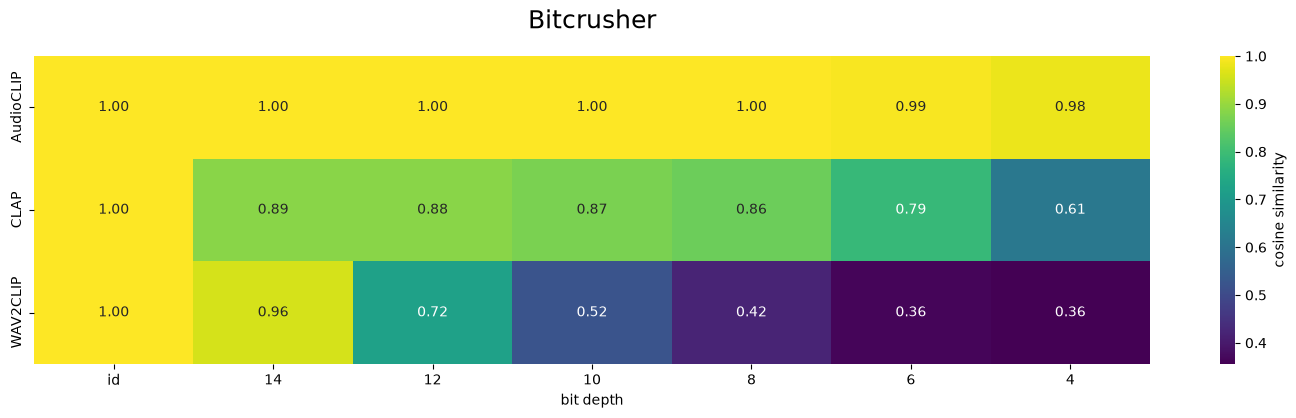

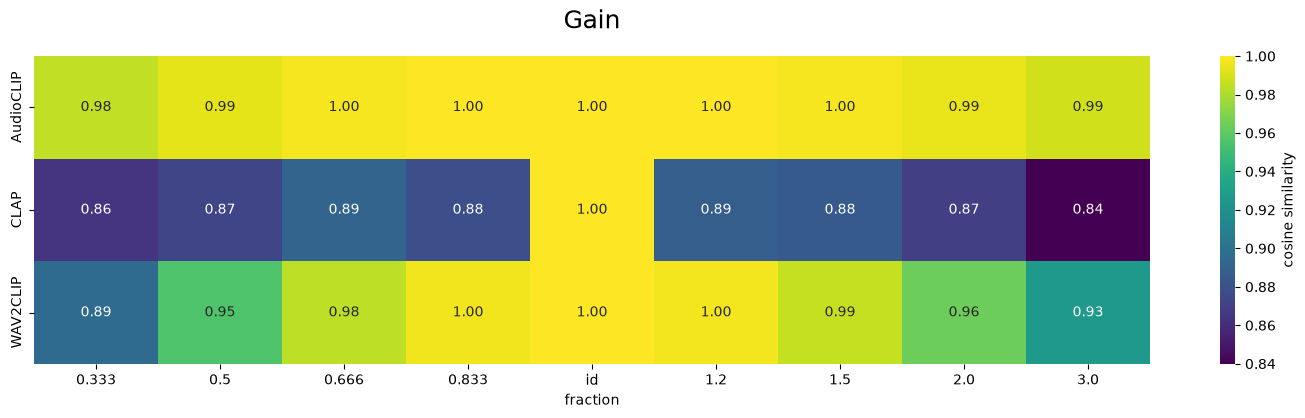

In [ ]:
for dataset in DATASETS:
    dataset = dataset.lower()
    for calc_mode in CALC_MODES:
        calc_mode = calc_mode.lower()
        for transformation in tf_dict_params.keys():
            transformation = transformation.lower()
            params = [str(param)[:5] for param in tf_dict_params[transformation]]
            df = pd.DataFrame(columns=params, index=MODELS, dtype=float)
            for model in MODELS:
                file = f"{calc_mode}_{dataset}_{model.lower()}_{transformation}.csv"
                file_path = os.path.join(READ_CSV[calc_mode], file)
                data = pd.read_csv(file_path, index_col=0)
                for param in params:
                    df.loc[model, param] = data.loc["id", param]
            plt.figure(figsize=(18, 4))
            calc_legend = CALC_LEGEND[calc_mode]
            sns.heatmap(df, annot=True, fmt=".2f", cmap=CALC_MODE_CM[calc_mode], cbar_kws={"label": calc_legend})            
            plt.title(tf_dict_names[transformation], fontsize=18, pad=20)
            plt.xlabel(tf_dict_legends[transformation])
            Path(SAVE_PATH).mkdir(parents=True, exist_ok=True)
            save_file = f"{calc_mode}_{dataset}_{transformation}"
            plt.savefig(os.path.join(SAVE_PATH, save_file+".png"), dpi=300, bbox_inches="tight")
            plt.show()
            df.to_csv(os.path.join(SAVE_PATH, save_file+".csv"), index=True)
            del(df)                

